# 01 — Cohort Description & Labeling Analysis
This notebook explores the study cohort derived from the Medallion pipeline and validates the KDIGO-based AKI labeling.

> **Data Source**: `gold_hourly_clinical` table produced by `pipeline/jobs/gold.py`

In [4]:
import sys
sys.path.insert(0, '..')

from src.data_loader import load_gold_table, train_test_split_by_stay
import pandas as pd
import matplotlib.pyplot as plt

df = load_gold_table()

Loaded 2,304,561 hourly samples across 72,082 stays.


## 1.1 Cohort Demographics

In [10]:
# One row per stay for demographic statistics
stays = df.drop_duplicates(subset='stay_id')

print(f"Total ICU stays: {len(stays):,}")
print(f"Unique patients: {stays['patient_id'].nunique():,}")
print(f"\nGender Distribution:")
display(stays['gender'].value_counts())
print(f"\nAge Statistics:")
display(stays['age'].describe())

Total ICU stays: 72,082
Unique patients: 50,573

Gender Distribution:


gender
male      40172
female    31910
Name: count, dtype: int64


Age Statistics:


count    72082.000000
mean        64.589148
std         16.759280
min         18.000000
25%         54.000000
50%         66.000000
75%         77.000000
max         90.000000
Name: age, dtype: float64

## 1.2 AKI Prevalence (Stay-Level)

In [6]:
# A stay has AKI if any of its hourly snapshots has aki_within_6h = 1
stay_aki = df.groupby('stay_id')['aki_within_6h'].max().reset_index()
stay_aki.columns = ['stay_id', 'developed_aki']

print(f"Stays that developed AKI: {stay_aki['developed_aki'].sum():,}")
print(f"Stays without AKI:        {(stay_aki['developed_aki'] == 0).sum():,}")
print(f"AKI prevalence:           {stay_aki['developed_aki'].mean():.1%}")

Stays that developed AKI: 39,304
Stays without AKI:        32,778
AKI prevalence:           54.5%


## 1.3 Target Distribution (Hourly-Level)

In [7]:
target_counts = df['aki_within_6h'].value_counts()
print(f"Negative samples (safe hours):          {target_counts.get(0, 0):,}")
print(f"Positive samples (AKI within 6h):       {target_counts.get(1, 0):,}")
print(f"Class ratio (neg:pos):                  {target_counts.get(0,0) / max(target_counts.get(1,1), 1):.1f}:1")

Negative samples (safe hours):          2,083,777
Positive samples (AKI within 6h):       220,784
Class ratio (neg:pos):                  9.4:1


## 1.4 ICU Stay Length Distribution

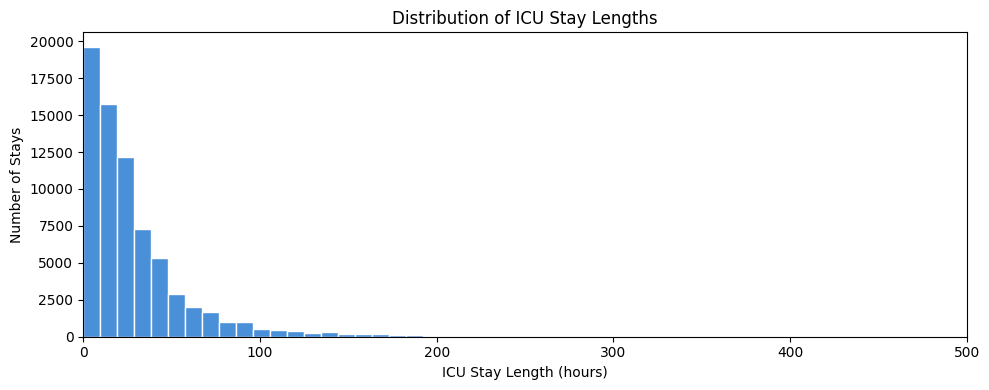

In [8]:
stay_lengths = df.groupby('stay_id')['hr_index'].max().reset_index()
stay_lengths.columns = ['stay_id', 'length_hours']

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(stay_lengths['length_hours'], bins=80, color='#4A90D9', edgecolor='white')
ax.set_xlabel('ICU Stay Length (hours)')
ax.set_ylabel('Number of Stays')
ax.set_title('Distribution of ICU Stay Lengths')
ax.set_xlim(0, 500)
plt.tight_layout()
plt.show()

## 1.5 Train/Test Split Verification

In [9]:
train_df, test_df = train_test_split_by_stay(df)

# Confirm no leakage
overlap = set(train_df['stay_id']) & set(test_df['stay_id'])
print(f"\nStay overlap between train and test: {len(overlap)} (must be 0)")

Train: 1,842,484 samples (57,665 stays)
Test:  462,077 samples (14,417 stays)

Stay overlap between train and test: 0 (must be 0)
